### Data Cleaning and Preparation

In [1]:
## Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
## Load the Dataset
df = pd.read_csv("Cardiotocographic.csv")
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [3]:
## Understand the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [4]:
## Missing Value
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [5]:
df.fillna(df.mean(), inplace=True)


In [6]:
df.dropna(inplace=True)

In [7]:
df.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

### Statistical Summary

In [8]:
df.describe()
## Average baseline fetal heart rate ~ 134 bpm
## Some variables have large variation, indicating possible outliers.

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.214328,0.004370,0.067540,0.003340,0.003343,0.000141,0.000836,18.813973,1.173632,21.205041,7.734356,42.719161,0.642424,0.641426
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001668,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.500000,68.000000,0.000000,1.000000
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


In [9]:
df.duplicated().sum()

2

In [10]:
df.dropna(inplace=True)

<function matplotlib.pyplot.show(close=None, block=None)>

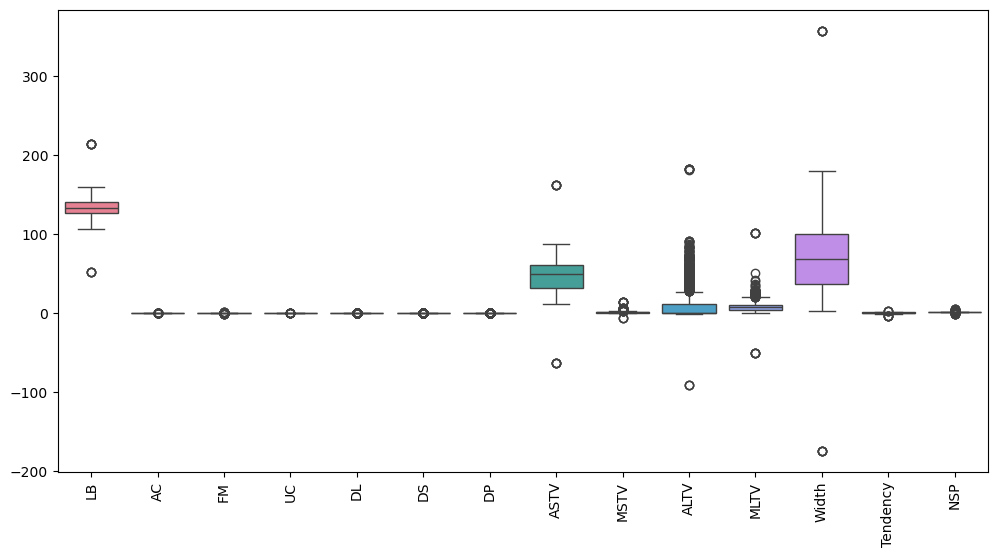

In [13]:
## Detect Oulier using box plot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show
# Boxplot shows extreme values.
# Outliers may represent unusual fetal conditions.

<function matplotlib.pyplot.show(close=None, block=None)>

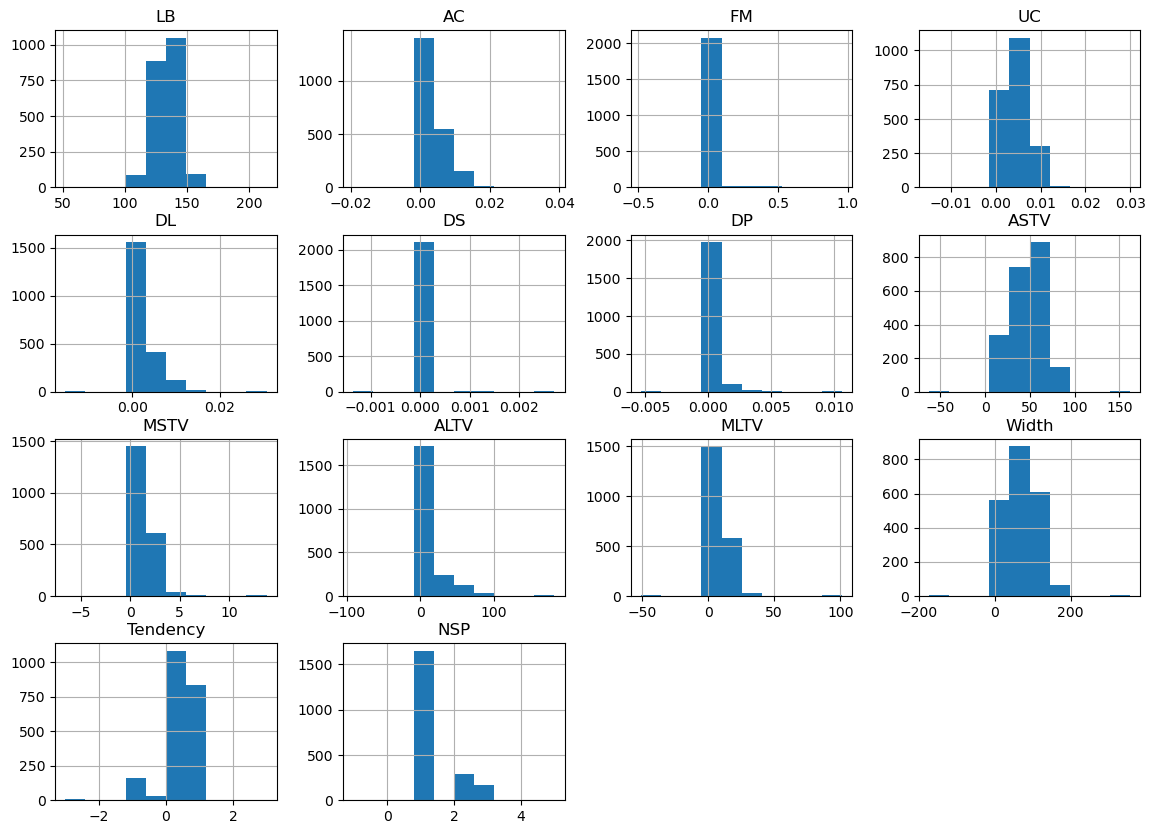

In [16]:
df.hist(figsize=(14,10))
plt.show
## Histogram shows the distribution of each variable
## Some features are normally distributed
## Some are skewed


<function matplotlib.pyplot.show(close=None, block=None)>

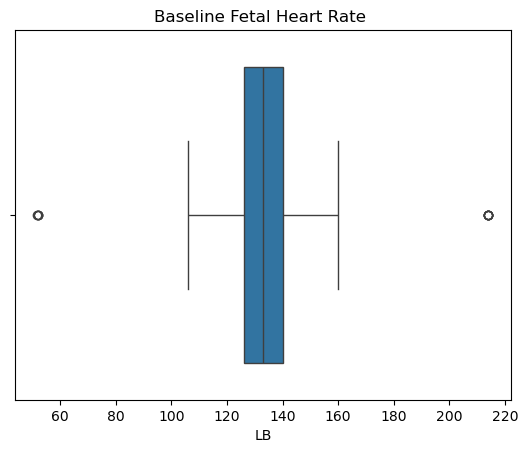

In [17]:
sns.boxplot(x=df['LB'])
plt.title("Baseline Fetal Heart Rate ")
plt.show

In [19]:
## correlation
corr = df.corr()
corr

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,-0.062839,0.018776,-0.166201,-0.126536,-0.005438,-0.047724,0.241857,-0.169561,0.210446,-0.003457,-0.118425,0.236864,0.131843
AC,-0.062839,1.000000,0.009432,0.071863,-0.093196,-0.033101,-0.083277,-0.230439,0.133649,-0.271041,-0.104875,0.234735,0.031977,-0.312022
FM,0.018776,0.009432,1.000000,-0.053226,0.009718,0.029899,0.121274,-0.032691,0.017055,-0.011936,-0.006237,0.097204,-0.018338,0.074048
UC,-0.166201,0.071863,-0.053226,1.000000,0.190128,-0.006922,0.070501,-0.181161,0.189406,-0.227304,-0.049351,0.107159,-0.066463,-0.185001
DL,-0.126536,-0.093196,0.009718,0.190128,1.000000,0.058430,0.144940,-0.069361,0.410102,-0.186967,-0.165198,0.408664,-0.023490,0.025342
DS,-0.005438,-0.033101,0.029899,-0.006922,0.058430,1.000000,0.004285,0.008425,0.016077,-0.004392,0.034349,0.040832,-0.015398,0.065400
DP,-0.047724,-0.083277,0.121274,0.070501,0.144940,0.004285,1.000000,0.038117,0.119250,-0.077654,-0.114084,0.175340,-0.130395,0.294472
ASTV,0.241857,-0.230439,-0.032691,-0.181161,-0.069361,0.008425,0.038117,1.000000,-0.293882,0.357497,-0.219728,-0.206942,-0.010892,0.421313
MSTV,-0.169561,0.133649,0.017055,0.189406,0.410102,0.016077,0.119250,-0.293882,1.000000,-0.291935,0.028779,0.433064,-0.036660,-0.094630
ALTV,0.210446,-0.271041,-0.011936,-0.227304,-0.186967,-0.004392,-0.077654,0.357497,-0.291935,1.000000,-0.107568,-0.345997,0.036722,0.365357


### +1  +ve correlation
### -1  -ve correlation
###  0 no correlation


<function matplotlib.pyplot.show(close=None, block=None)>

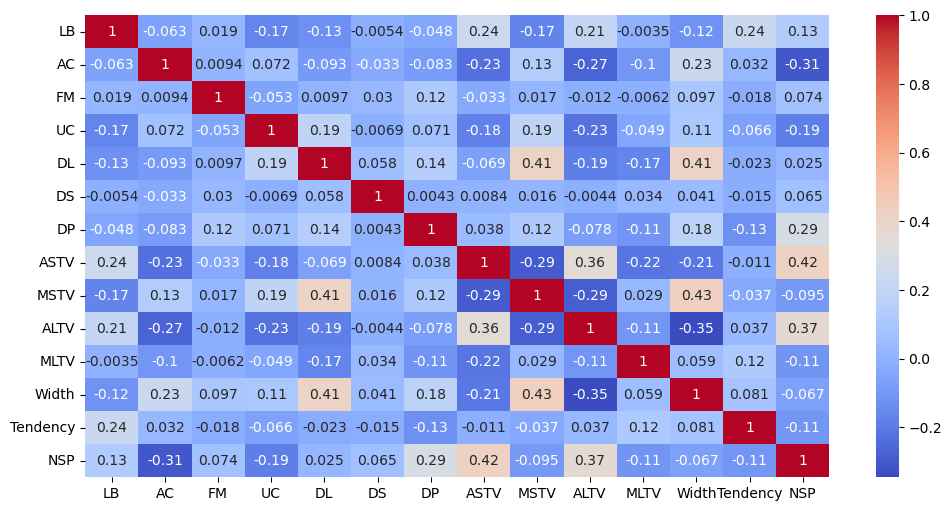

In [20]:
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show
# Heatmap helps visually see which variables are strongly related
# ASTV and ALTV may show correlation
# MSTV and MLTV relate to variability patterns

<function matplotlib.pyplot.show(close=None, block=None)>

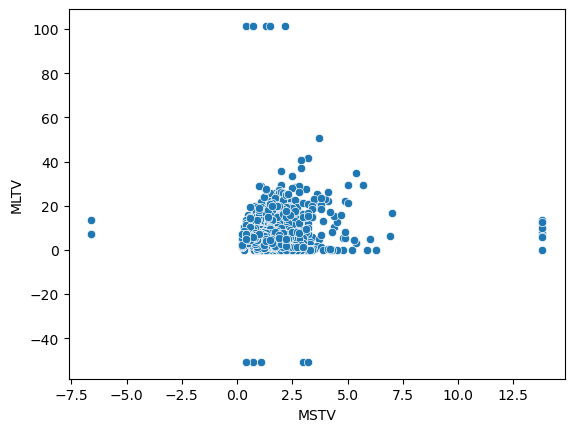

In [21]:
## Scatter Plot
sns.scatterplot(x='MSTV',y='MLTV',data=df)
plt.show
# Explanation
# Shows relationship between:
# Short term variability
# Long term variability
# Clusters may appear showing different fetal conditions

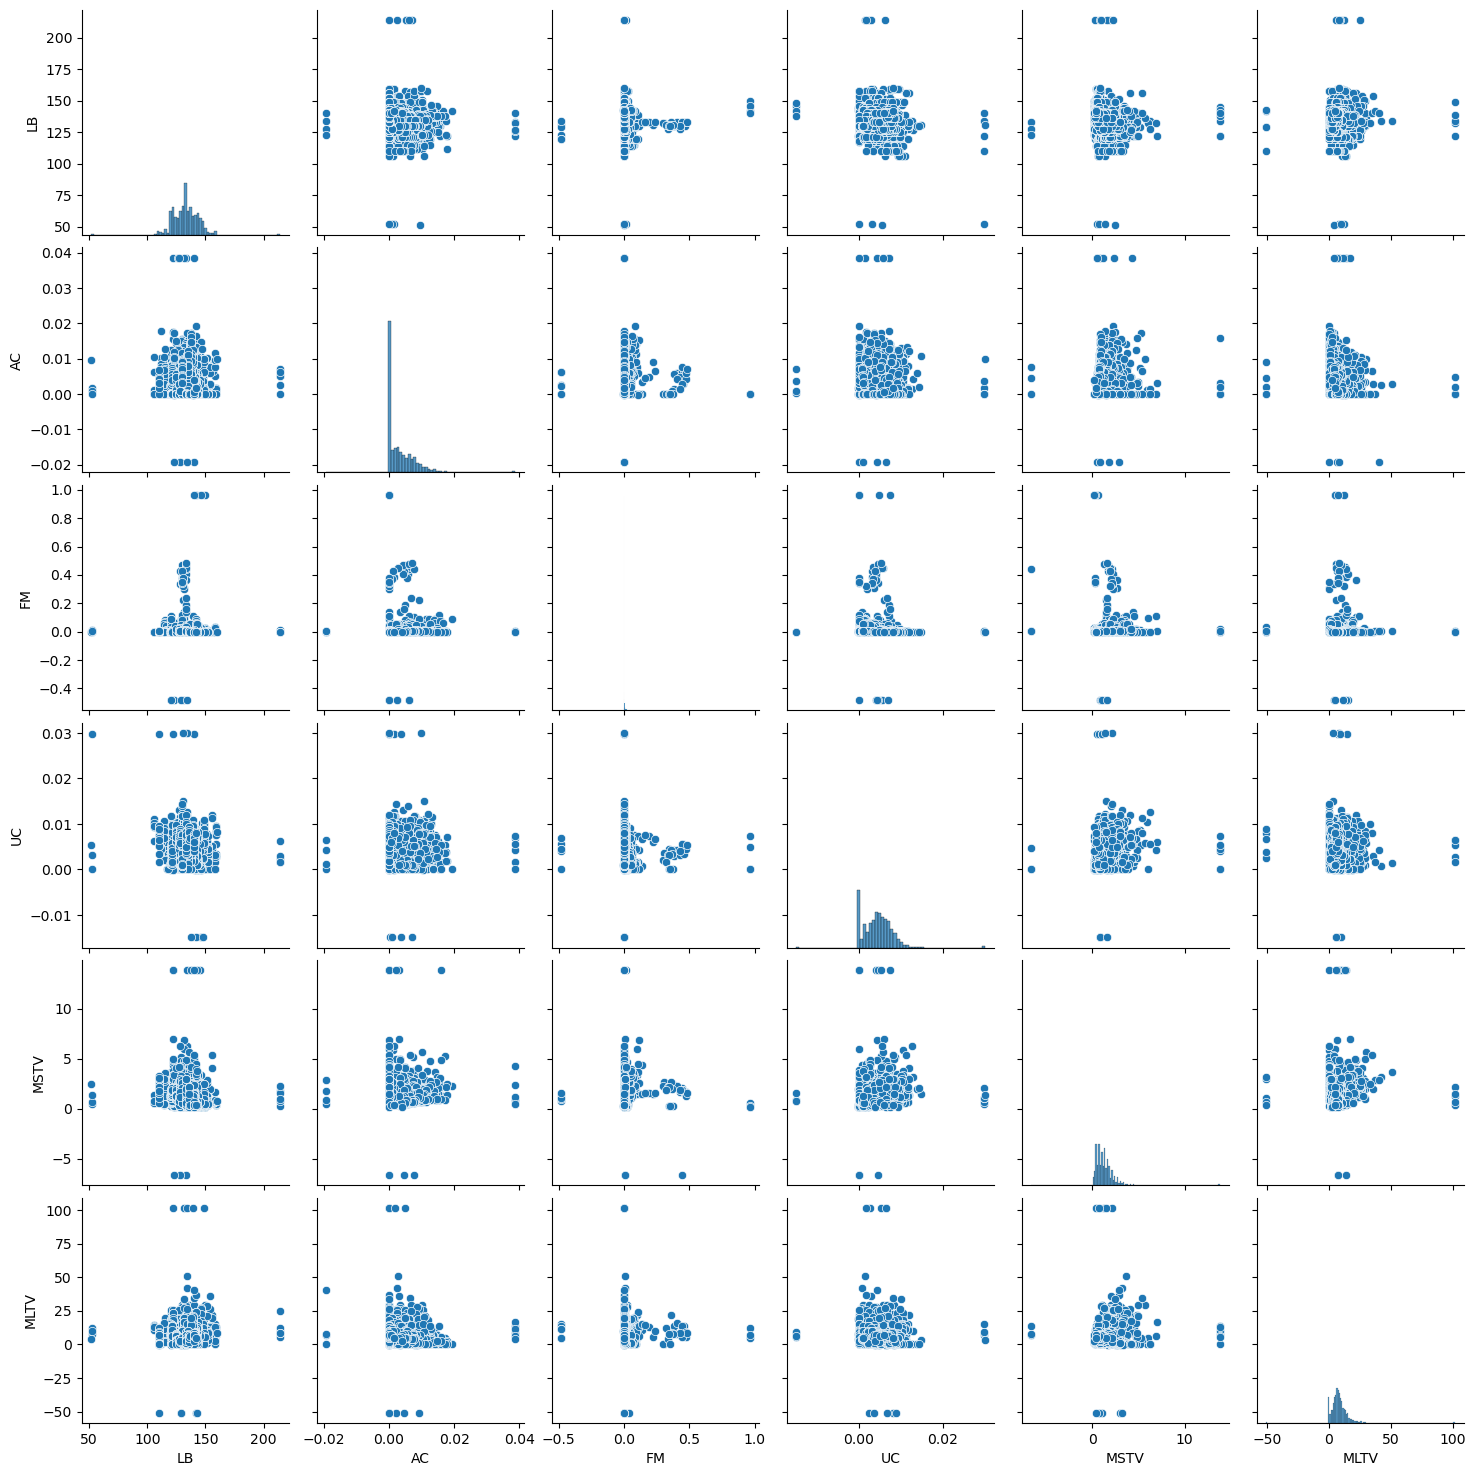

In [26]:
#Pairplot 
# Pairplot shows:
# Scatter plots between variables
# Distribution of each variable
# Useful to identify:
# clusters
# patterns
# correlations
sns.pairplot(df[['LB','AC','FM','UC','MSTV','MLTV']])
plt.show()

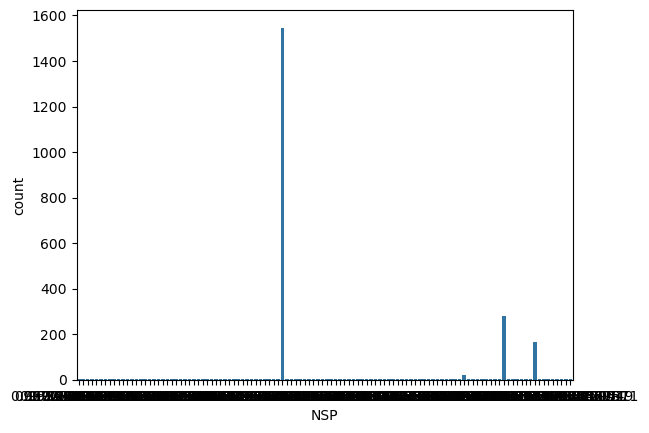

In [35]:
sns.countplot(x=df['NSP'])
plt.show()
# Most cases are Normal
# Fewer are Pathological

# Pattern Recognition
### Pattern Recognition
### Accelerations (AC) often associated with healthy fetal condition
### High ASTV or ALTV may indicate abnormal fetal variability
### Short term and long term variability show relationships
### NSP class imbalance(Normal cases dominate dataset)

# Key Insights
### Fetal heart rate values mostly fall in the normal physiological range

### Variability metrics (MSTV, MLTV) help detect fetal distress

### Some variables have skewed distributions

###  Strong correlations exist among variability features

###  Dataset contains different fetal state classes

# Conclusion
### Most fetal heart rate observations lie within normal limits.
### Variability indicators such as ASTV, MSTV, ALTV, MLTV play a crucial role in detecting abnormal fetal conditions.
### The dataset shows correlations among variability metrics, suggesting they collectively influence fetal state classification.
### Visualization techniques such as histograms, boxplots, scatter plots, and heatmaps helped identify patterns and relationships between variables
